# Analyse MRIqc results
VPMB dataset after spin-echo distortion correction

Some guides:
- https://towardsdatascience.com/statsannotations-add-statistical-significance-annotations-on-seaborn-plots-6b753346a42a

In [1]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")
from itertools import combinations
from statannotations.Annotator import Annotator
import os

In [2]:
# dataset path
wd = os.path.abspath('..')
mriqc_data_file = os.path.join(wd, 'data', 'mriqc_group_bold.tsv')

# import tsv file
mriqc_data = pandas.read_csv(mriqc_data_file, sep='\t')

In [3]:
# view
mriqc_data.head()

,bids_name,aor,aqi,dummy_trs,dvars_nstd,dvars_std,dvars_vstd,efc,fber,fd_mean,...,summary_bg_stdv,summary_fg_k,summary_fg_mad,summary_fg_mean,summary_fg_median,summary_fg_n,summary_fg_p05,summary_fg_p95,summary_fg_stdv,tsnr
0,sub-01_task-AA_acq-0500_run-1_bold,0.000380,0.012249,0,38.513725,1.184230,1.000107,0.559338,2739.041504,0.135953,...,851.424866,1.649877,1475.115367,9509.383789,9454.779297,55810.0,7194.165796,12113.792725,1575.965332,44.324478
1,sub-01_task-AA_acq-0750_run-1_bold,0.003095,0.018335,0,31.113940,1.157902,1.005471,0.573185,1964.504272,0.173606,...,1054.709961,1.629401,1719.699849,11489.869141,11414.047852,55209.0,8800.758789,14522.333984,1835.968140,41.413017
2,sub-01_task-AA_acq-1000_run-1_bold,0.002101,0.010108,0,26.585327,1.147315,1.024456,0.562032,2195.935791,0.183129,...,1150.837036,1.888404,1989.607294,12697.009766,12607.363281,55857.0,9533.901367,16235.122070,2160.396729,53.205177
3,sub-01_task-AA_acq-2500_run-1_bold,0.000578,0.003224,0,32.594990,1.197928,0.989386,0.577387,235.130478,0.055899,...,1708.341919,2.871521,5049.588236,14477.243164,13280.972656,55918.0,7387.377246,25994.709277,5953.833984,53.576714
4,sub-01_task-UA_acq-0500_run-1_bold,0.000574,0.012481,4,38.444725,1.185641,1.003976,0.559465,2759.964600,0.142584,...,856.946716,1.579121,1462.826708,9500.787109,9440.989258,55694.0,7207.778442,12120.166553,1565.237061,43.777832


In [9]:
# define TR pairs (for stat analysis)
TRs = ['500', '750', '1000', '2500']
TR_pairs = list(combinations(TRs, r=2))

# def get_var_per_tr(df: pandas.DataFrame, tr: str, var: str):
#     return df.loc[(df.TR == tr), "snr"].values

# add column to mriqc_data with TR based on bids_name if contains acq-0500
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-0500'), 'TR'] = '500'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-0750'), 'TR'] = '750'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-1000'), 'TR'] = '1000'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-2500'), 'TR'] = '2500'

# check
mriqc_data.head()

,bids_name,aor,aqi,dummy_trs,dvars_nstd,dvars_std,dvars_vstd,efc,fber,fd_mean,...,summary_fg_k,summary_fg_mad,summary_fg_mean,summary_fg_median,summary_fg_n,summary_fg_p05,summary_fg_p95,summary_fg_stdv,tsnr,TR
0,sub-01_task-AA_acq-0500_run-1_bold,0.000380,0.012249,0,38.513725,1.184230,1.000107,0.559338,2739.041504,0.135953,...,1.649877,1475.115367,9509.383789,9454.779297,55810.0,7194.165796,12113.792725,1575.965332,44.324478,500
1,sub-01_task-AA_acq-0750_run-1_bold,0.003095,0.018335,0,31.113940,1.157902,1.005471,0.573185,1964.504272,0.173606,...,1.629401,1719.699849,11489.869141,11414.047852,55209.0,8800.758789,14522.333984,1835.968140,41.413017,750
2,sub-01_task-AA_acq-1000_run-1_bold,0.002101,0.010108,0,26.585327,1.147315,1.024456,0.562032,2195.935791,0.183129,...,1.888404,1989.607294,12697.009766,12607.363281,55857.0,9533.901367,16235.122070,2160.396729,53.205177,1000
3,sub-01_task-AA_acq-2500_run-1_bold,0.000578,0.003224,0,32.594990,1.197928,0.989386,0.577387,235.130478,0.055899,...,2.871521,5049.588236,14477.243164,13280.972656,55918.0,7387.377246,25994.709277,5953.833984,53.576714,2500
4,sub-01_task-UA_acq-0500_run-1_bold,0.000574,0.012481,4,38.444725,1.185641,1.003976,0.559465,2759.964600,0.142584,...,1.579121,1462.826708,9500.787109,9440.989258,55694.0,7207.778442,12120.166553,1565.237061,43.777832,500


# SNR (Signal to noise ratio)
The estimation may be provided with only one foreground region in which the noise is computed as follows:

$$ SNR = \frac{\mu_F}{\sigma _F \sqrt{\frac{n}{n-1}}} $$

where $\mu_F$ is the mean intensity of the foreground and $\sigma_F$ is the standard deviation of the same region. Higher values are better.

In [10]:
# estimate mean and std of snr for each TR and print them
snr_mean = mriqc_data.groupby('TR')['snr'].mean()
snr_std = mriqc_data.groupby('TR')['snr'].std()

print('snr mean per TR:')
print(snr_mean)
print('snr std per TR:')
print(snr_std)

# this reveals the big difference is in the mean of SNR, not std.

snr mean per TR:
TR
1000    6.120141
2500    2.259066
500     6.211847
750     6.344375
Name: snr, dtype: float64
snr std per TR:
TR
1000    0.422521
2500    0.232052
500     0.392705
750     0.395373
Name: snr, dtype: float64


[Text(0.5, 0, 'TR (milliseconds)'), Text(0, 0.5, 'SNR')]

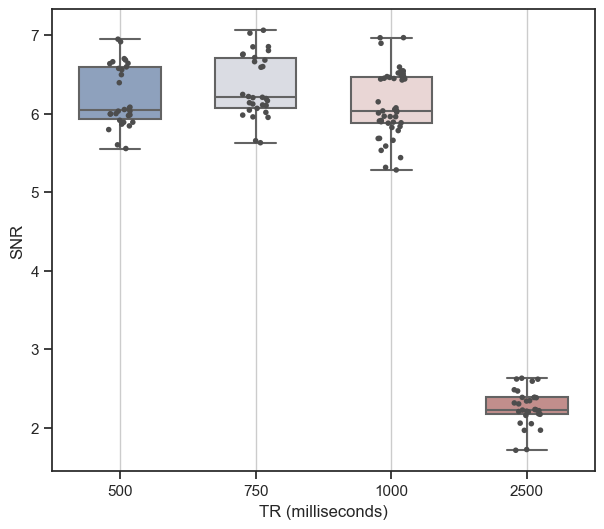

In [11]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="snr", data=mriqc_data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="snr", data=mriqc_data,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="SNR")
#sns.despine(trim=True, left=True)

#annotator = Annotator(ax, TR_pairs, data=mriqc_data, x='TR', y='snr', order=TRs)
#annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
#annotator.apply_and_annotate()

/tmp/ipykernel_19492/2976170099.py:3: RuntimeWarning: divide by zero encountered in divide
  y = np.sqrt(x/(x-1))


Values of x:  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 

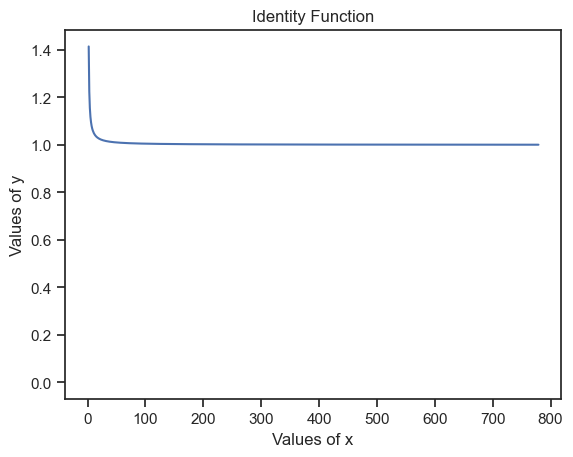

In [14]:
import numpy as np
x = np.arange(0, 780, 1)
y = np.sqrt(x/(x-1))
print('Values of x: ', x)
print('Values of y: ', y)
plt.plot(x, y)
plt.title("Identity Function")
plt.xlabel("Values of x")
plt.ylabel("Values of y")
plt.show()

# Temporal SNR
We report the median value of the tSNR map calculated like:

$$ tSNR = \frac{S_t}{\sigma_t} $$

where $S_t$ is the average BOLD signal (across time), and $\sigma_t$ is the corresponding temporal standard-deviation map. Higher values are better.

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided, P_val:5.186e-07 U_stat=1.100e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:3.687e-03 U_stat=4.060e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:1.560e-03 U_stat=9.680e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:1.259e-09 U_stat=1.130e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:6.309e-01 U_stat=4.830e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:3.831e-05 U_stat=1.710e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='tSNR'>,
  <statannotations.Annotation.Annotation at 0x7f4349f2cc10>])

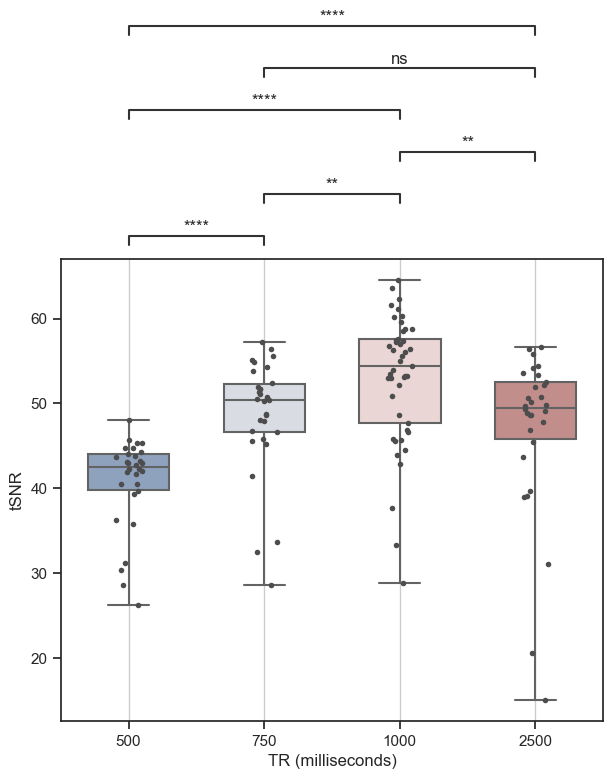

In [16]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="tsnr", data=mriqc_data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="tsnr", data=mriqc_data,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="tSNR")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs, data=mriqc_data, x='TR', y='tsnr', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
annotator.apply_and_annotate()

# AQI (AFNI’s quality index)
Mean quality index as computed by AFNI’s 3dTqual; for each volume, it is one minus the Spearman’s (rank) correlation of that volume with the median volume. Lower values are better.

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided, P_val:2.380e-03 U_stat=6.560e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:4.484e-02 U_stat=8.610e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:5.754e-09 U_stat=1.214e+03
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:2.296e-05 U_stat=1.067e+03
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:4.311e-08 U_stat=8.210e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:9.260e-09 U_stat=8.390e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='AQI'>,
  <statannotations.Annotation.Annotation at 0x7f4348ff4990>])

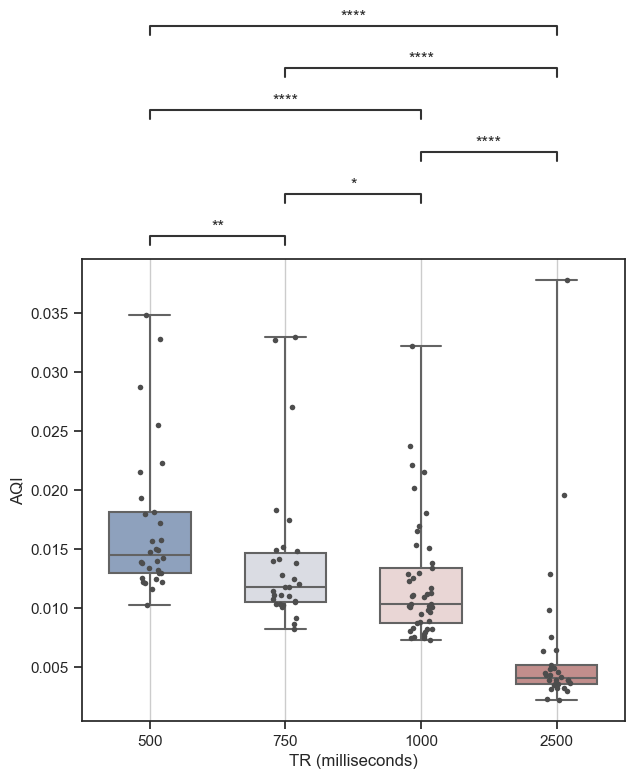

In [17]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="aqi", data=mriqc_data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="aqi", data=mriqc_data,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="AQI")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs, data=mriqc_data, x='TR', y='aqi', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
annotator.apply_and_annotate()


# FWHM (Full-width half-maximum smoothness)
The FWHM of the spatial distribution of the image intensity values in units of voxels.
Lower values are better, higher values indicate a blurrier image. 

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided, P_val:1.624e-01 U_stat=5.450e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:6.930e-01 U_stat=7.120e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:2.996e-13 U_stat=0.000e+00
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:5.093e-02 U_stat=8.560e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:3.020e-11 U_stat=0.000e+00
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:3.020e-11 U_stat=0.000e+00


(<Axes: xlabel='TR (milliseconds)', ylabel='FWHM (average)'>,
  <statannotations.Annotation.Annotation at 0x7f43490d0450>])

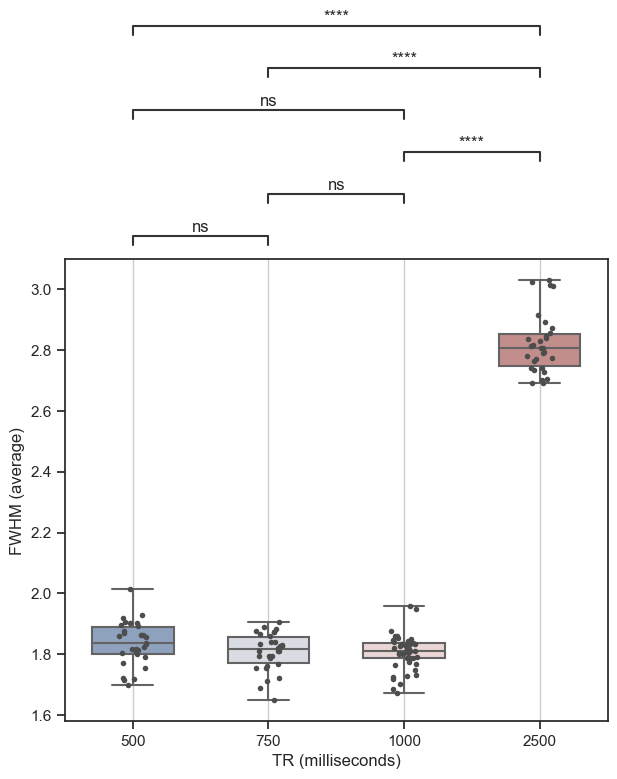

In [18]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="fwhm_avg", data=mriqc_data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="fwhm_avg", data=mriqc_data,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="FWHM (average)")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs, data=mriqc_data, x='TR', y='fwhm_avg', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
annotator.apply_and_annotate()
